# Sub-Hypothesis Exploration

This notebook investigates additional research questions:
1. **Class size vs Student Enjoyment** (enrollment vs recommendation rate)
2. **Quarter-Based Analysis** (do students perform better in certain quarters?)
3. **Study Hours vs GPA** by quarter and department


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
root_dir = next((path for path in [cwd, *cwd.parents] if (path / "src").exists() and (path / "data" / "capes_data.csv").exists()), None)
if root_dir is None:
    raise FileNotFoundError("Could not find the project root from the current notebook working directory.")
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.capes_analysis import clean_capes_analysis_frame, load_capes_data
from src import sub_hypothesis_helpers as sh

df_raw = load_capes_data(root_dir / 'data' / 'capes_data.csv')
df_clean = clean_capes_analysis_frame(df_raw)

print(f'Clean rows: {len(df_clean):,}')
print(f'Seasons: {df_clean["Season_Name"].value_counts().to_dict()}')



Clean rows: 41,179
Seasons: {'Winter': 14121, 'Spring': 13791, 'Fall': 13267}


## 2. Class Size vs Student Enjoyment

### 2.1 Enrollment vs Recommendation Rate (Scatter)

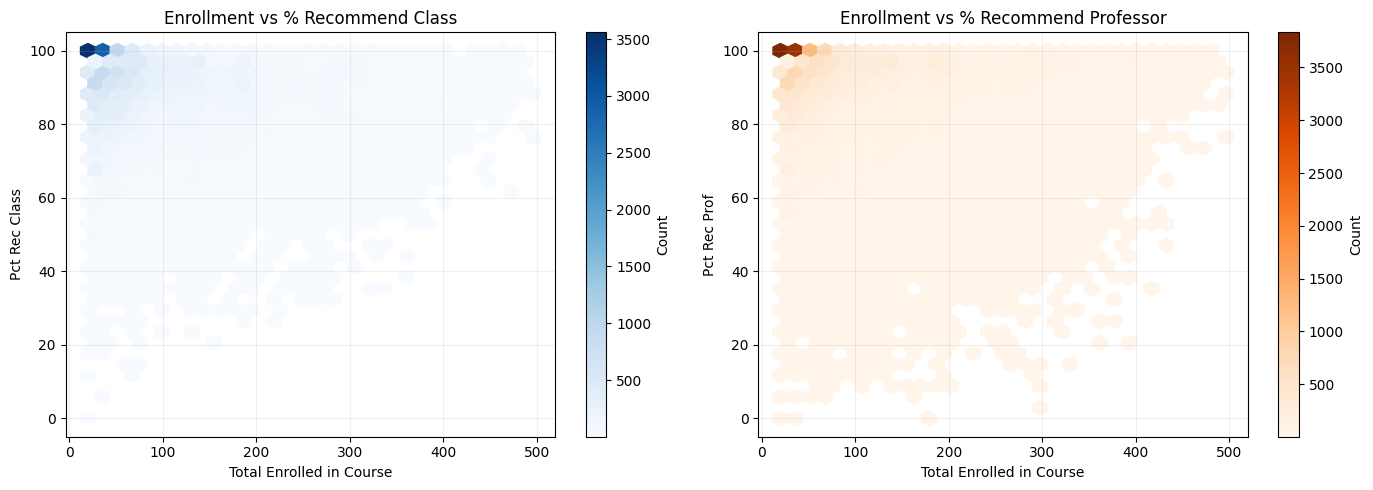

In [2]:
df_size = sh.prepare_class_size_frame(df_clean)
sh.plot_class_size_hexbin(df_size, 'figures/classsize_vs_rec.png')


### 2.2 Enrollment Bins vs Avg Recommendation Rate

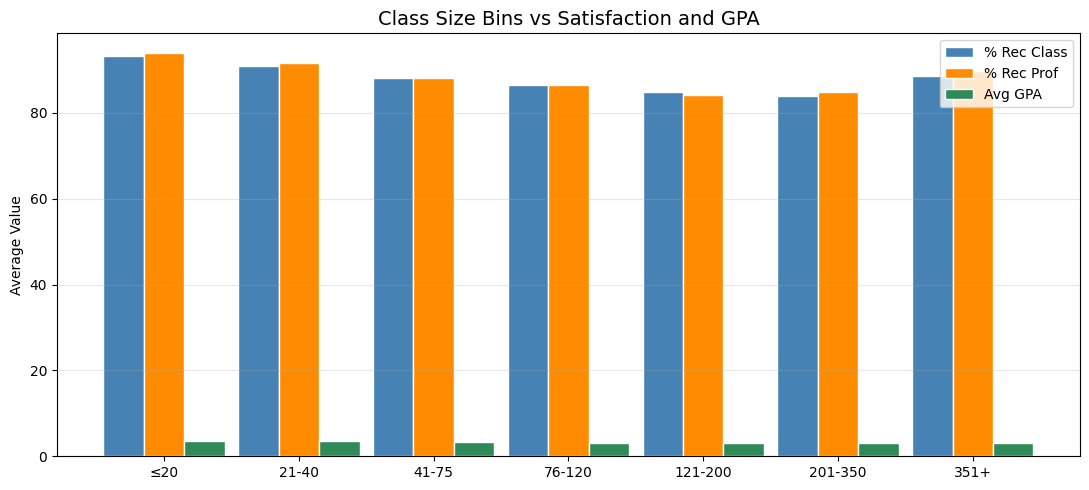

,Pct_Rec_Class,Pct_Rec_Prof,GPA_Received
Size_Bin,,,
≤20,93.283,93.837,3.565
21-40,91.035,91.686,3.460
41-75,88.164,88.231,3.284
76-120,86.606,86.442,3.182
121-200,84.895,84.076,3.127
201-350,83.968,84.863,3.080
351+,88.629,89.764,3.189


In [3]:
df_size = sh.add_size_bins(df_size)
bin_stats = sh.summarize_size_bins(df_size)
sh.plot_size_bin_summary(bin_stats, 'figures/classsize_bins.png')
bin_stats.round(3)


## 3. Quarter-Based Analysis

**Question**: Do students perform better in certain quarters (Fall / Winter / Spring / Summer)?

### 3.1 GPA by Season (Overall)

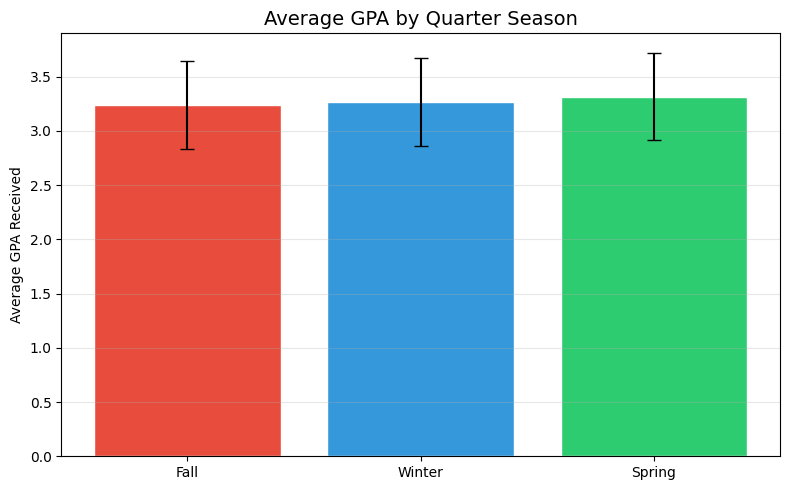

,mean,std,count
Season_Name,,,
Fall,3.240,0.403,13267.0
Winter,3.269,0.405,14121.0
Spring,3.314,0.400,13791.0
Summer,NaN,NaN,NaN


In [4]:
df_season, season_order = sh.prepare_season_frame(df_clean)
season_gpa = sh.summarize_season_gpa(df_season, season_order)
sh.plot_season_gpa(season_gpa, 'figures/quarter_gpa.png')
season_gpa.round(3)


### 3.2 GPA by Season — Focus Departments

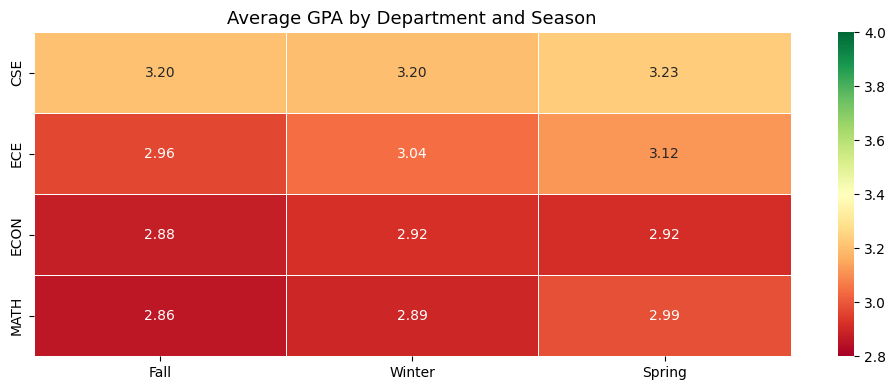

Season_Name,Fall,Winter,Spring
Department,,,
CSE,3.205,3.199,3.232
ECE,2.965,3.041,3.118
ECON,2.877,2.920,2.917
MATH,2.860,2.894,2.987


In [5]:
FOCUS = sh.focus_departments(df_season)
pivot = sh.build_season_department_heatmap(df_season, FOCUS, season_order)
sh.plot_season_department_heatmap(pivot, 'figures/quarter_dept_heatmap.png')
pivot.round(3)


### 3.3 Recommendation Rate by Season

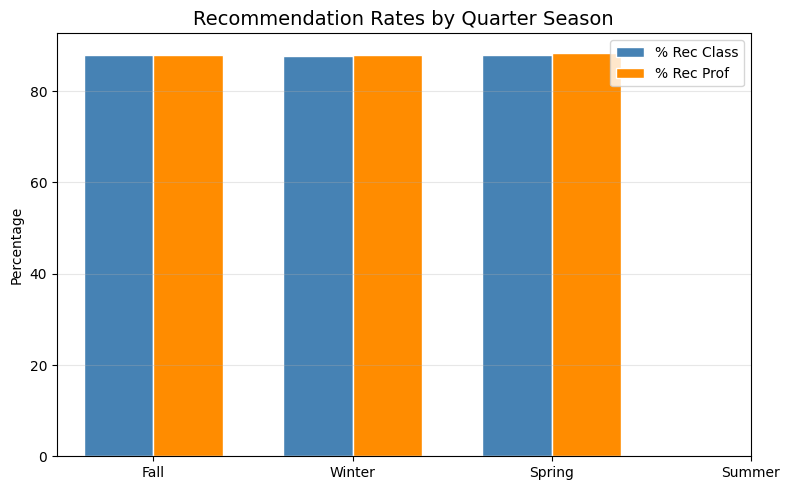

,Pct_Rec_Class,Pct_Rec_Prof
Season_Name,,
Fall,87.82,87.97
Winter,87.74,87.87
Spring,87.92,88.26
Summer,NaN,NaN


In [6]:
season_rec = sh.summarize_season_recommendations(df_season, season_order)
sh.plot_season_recommendations(season_rec, 'figures/quarter_rec_rate.png')
season_rec.round(2)


### 3.4 Study Hours by Season

/Users/jeevan/Library/Mobile Documents/com~apple~CloudDocs/College docs/Courses/ECE 143/ECE143_LLM_Impact/src/sub_hypothesis_helpers.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


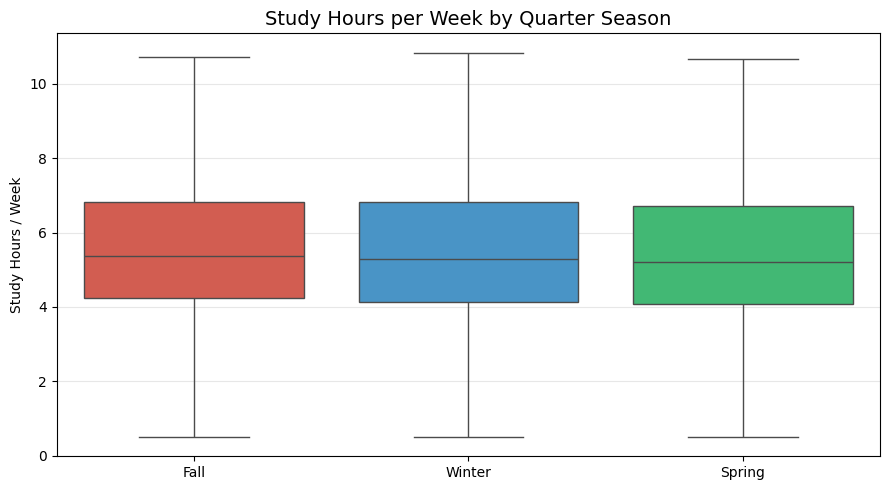

               count  mean   std  min   25%   50%   75%    max
Season_Name                                                   
Fall         13267.0  5.71  2.22  0.5  4.23  5.38  6.83  20.33
Spring       13791.0  5.65  2.33  0.5  4.09  5.22  6.72  18.88
Winter       14121.0  5.68  2.29  0.5  4.14  5.30  6.82  19.83


In [7]:
df_hours = sh.filter_season_hours(df_season)
sh.plot_season_study_hours(df_hours, season_order, 'figures/quarter_study_hours.png')
print(df_hours.groupby('Season_Name')['Study Hours per Week'].describe().round(2))


## 4. Summary — Sub-Hypothesis Findings

In [8]:
sh.print_sub_hypothesis_summary(df_size, season_gpa, df_hours)


=== Class Size vs Satisfaction ===
  Enrollment vs Rec Class:    r = -0.161
  Enrollment vs Rec Prof:     r = -0.135
  Enrollment vs GPA:          r = -0.286

=== GPA by Season ===
              mean    std    count
Season_Name                       
Fall         3.240  0.403  13267.0
Winter       3.269  0.405  14121.0
Spring       3.314  0.400  13791.0
Summer         NaN    NaN      NaN

=== Study Hours by Season ===
               count   mean    std  min   25%   50%    75%    max
Season_Name                                                      
Fall         13267.0  5.713  2.216  0.5  4.23  5.38  6.830  20.33
Spring       13791.0  5.649  2.325  0.5  4.09  5.22  6.725  18.88
Winter       14121.0  5.681  2.293  0.5  4.14  5.30  6.820  19.83
